
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2025**

---

# Trabajo práctico entregable - Parte 2

Grupo 26: Astoreca Pablo, Callen Ailen, Mendez Juan y Zamorano Micaela.

In [ ]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn as sns

#seaborn.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [ ]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2025_processed.csv'
df = pd.read_csv(url)

In [ ]:
df[:3]

,Unnamed: 0,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,...,salir_o_seguir_contestando_sobre_las_guardias,work_on_call_duty,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,profile_age,profile_gender,habias_respondido_nuestra_encuesta_en_ediciones_anteriores,sueldo_dolarizado,seniority,_sal
0,0,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),6500000.0,5800000.0,Cobro parte del salario en dólares,NaN,De uno a tres sueldos,Performance de la compañía,...,NaN,NaN,NaN,NaN,45,Hombre Cis,Sí,True,Senior,6500000.0
1,1,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,12700000.0,10200000.0,Cobro todo el salario en dólares,NaN,Un sueldo,Performance de la compañía,...,Terminar encuesta,No,0.0,Bruto,32,Mujer Cis,Sí,True,Senior,12700000.0
2,2,Córdoba,Full-Time,Staff (planta permanente),3952805.0,3137662.0,Cobro parte del salario en dólares,985,No,No recibo bono,...,NaN,NaN,NaN,NaN,29,Hombre Cis,Sí,True,Semi-Senior,3952805.0


In [ ]:
df.profile_gender.unique()

array(['Hombre Cis', 'Mujer Cis', 'No binarie', 'Prefiero no decir', nan,
       'Trans', 'Queer', 'Lesbiana', 'Agénero'], dtype=object)

In [ ]:
df.loc[:,'profile_g'] = df.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

In [ ]:
alpha = 0.05

In [ ]:
is_man = df.profile_g == 'Varón cis'
is_woman = df.profile_g == 'Mujer cis'


In [ ]:
groupA = df[(15000000>df.salary_monthly_NETO)&(df.salary_monthly_NETO > 100000) & is_man].salary_monthly_NETO
groupB  = df[(df.salary_monthly_NETO > 100000) & is_woman].salary_monthly_NETO


In [ ]:
print(f"Mean: {groupA.mean()}")
print(f"Median: {groupA.median()}")
print(f"Standard Deviation: {groupA.std()}")

Mean: 2403162.4648686917
Median: 2000000.0
Standard Deviation: 1606418.565282235


In [ ]:
print(f"Mean: {groupB.mean()}")
print(f"Median: {groupB.median()}")
print(f"Standard Deviation: {groupB.std()}")

Mean: 1926464.3164589824
Median: 1660669.0
Standard Deviation: 1246694.955339217


Text(0.5, 0, 'Salary')

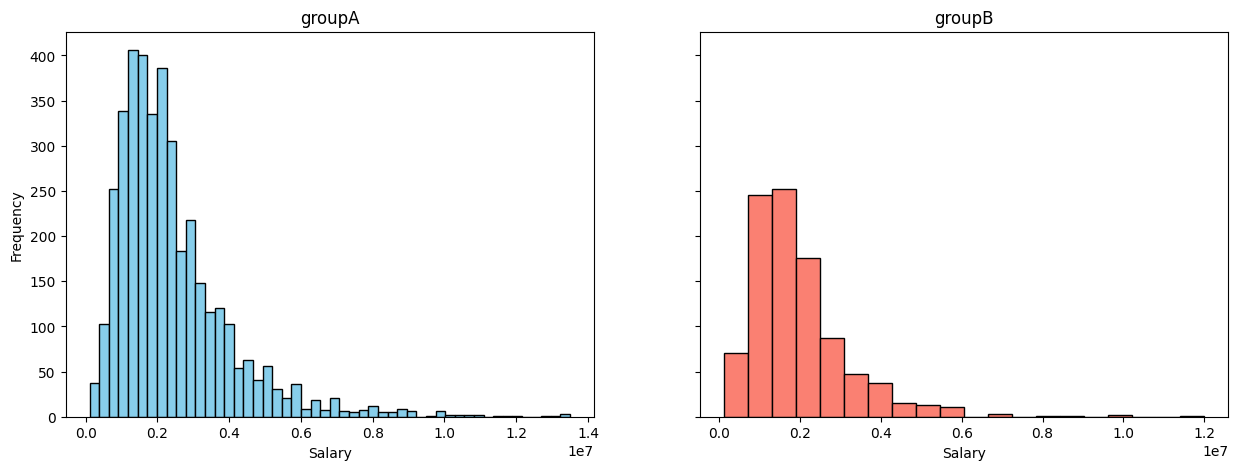

In [ ]:


# Create the histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)  # 1 row, 3 columns

# Plot each group on a separate subplot
axes[0].hist(groupA, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('groupA')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

axes[1].hist(groupB, bins=20, color='salmon', edgecolor='black')
axes[1].set_title('groupB')
axes[1].set_xlabel('Salary')





## Ejercicio 1: Estimación

**Consigna:**  Calcular una estimación puntual y un intervalo de confianza de nivel (1-alpha) para la resta entre la media del salario Neto para Hombres y la media del salario Neto para mujeres (diferencia de las medias entre el grupoA y grupoB).
¿Cómo se relaciona este intervalo de confianza con el test de hipótesis para diferencia de medias?

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats


# Estimación puntual (diferencia de medias)
mean_diff = groupA.mean() - groupB.mean()

# Tamaños de las muestras de los grupos
n1 = len(groupA)
n2 = len(groupB)

# Desviaciones estándar
s1 = groupA.std(ddof=1)
s2 = groupB.std(ddof=1)

# Error estándar de la diferencia de medias
se_diff = np.sqrt(s1**2/n1 + s2**2/n2)

# Grados de libertad aproximados (Welch)
df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
print(df_welch)

# Valor crítico t para el intervalo de confianza
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df_welch)

# Intervalo de confianza
ic_inferior = mean_diff - t_crit * se_diff
ic_superior = mean_diff + t_crit * se_diff

print(f"Diferencia de medias (Varón cis - Mujer cis): ${mean_diff:,.2f}")
print(f"Intervalo de confianza al 95%: [${ic_inferior:,.2f}, ${ic_superior:,.2f}]")


1839.826694806468
Diferencia de medias (Varón cis - Mujer cis): $476,698.15
Intervalo de confianza al 95%: [$383,082.86, $570,313.44]


Con un 95% de confianza, podemos afirmar que la diferencia del salario promedio mensual entre los varones y los mujeres esta entre 383.082  y  570.313 (pesos).

Naturalmente se puede considerar este intervalo como un criterio valido para el test de hipotesis a la hora de analizar algun resultado.

Respondiendo a la pregunta ¿Cómo se relaciona el intervalo de confianza con el test de hipotesis para la diferencia de medias? podemos decir que el intervalo de confianza y el test de hipotesis estan relacionados porque en el fondo los dos intentan responder lo mismo.

Cuando calculamos el intervalo de confianza para la diferencia de medias estamos obteniendo un rango de valores posibles para esa diferencia, con cierto nivel de confianza (95%).
Entonces si ese intervalo incluye el 0 podria no haber una diferencia real entre los grupos. Y si hicieramos un test de hipotesis no rechazariamos la hipotesis nula que dice que las medias son iguales.

Para nuestro ejemplo el intervalo calculado no contiene el 0 entonces si hay evidencia de que hay una diferencia real, y el test de hipotesis daria como resultado que rechazamos la hipotesis nula.

## Ejercicio 2: Test de hipótesis



### 2.1 Formalización

Describir formalmente los distintos componentes de un test de hipótesis para comprobar si la distribución de los salarios es distinta entre los grupos A y B.



✅ Hipótesis nula y alternativa

Queremos saber si la distribución de salarios mensuales netos difiere entre varones cis (groupA) y mujeres cis (groupB).

Hipótesis nula (H₀):

$H_0 = \mu_A - \mu_B = 0$

No hay diferencia significativa en los salarios medios entre varones cis y mujeres cis.

Hipótesis alternativa (H₁):

$H_a = \mu_A - \mu_B \neq 0$

Hay una diferencia significativa entre los salarios medios.

✅ Estadístico (Pivote)
  * Identificar el estadístico

El estadístico usado para esta prueba de hipótesis fue: $Z= \frac{(\overline{X_1}-\overline{X_2}) - (\mu_1 - \mu_2)}{\sqrt{\frac{S_1^2}{n_1}+ \frac{S_1^2}{n_2}}}$ con:

$\overline{X_1}, S_1 , n_1$ el  Salario medio de los hombres, la desviacion estandar y la cantidad de personas respectivamente.

$\overline{X_2}, S_2 , n_2$ el  Salario medio de las mujeres, la desviacion estandar y la cantidad de personas respectivamente.


En el caso de ser afirmativo $H_0$ tenemos que $\mu_1 = \mu_2$ por lo que $Z= \frac{(\overline{X_1}-\overline{X_2})}{\sqrt{\frac{S_1^2}{n_1}+ \frac{S_1^2}{n_2}}}$, que sigue una distribución t de Student con 1839 grados de libertad, ya que no conocemos las desviaciones estándar poblacionales.




In [ ]:
print(df_welch)

1839.826694806468


### 2.2 P-valor

1. Calcule el p-valor y decida si rechazar o no la hipótesis nula.
2. Interprete el resultado.

Links útiles:
* [Test de hipótesis usando scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
* [Test de Welch](http://daniellakens.blogspot.com/2015/01/always-use-welchs-t-test-instead-of.html)

In [ ]:
import scipy.stats as stats

# Test T-Student para group a y b, equal_var=False le dice al test que NO suponga que las dos poblaciones tienen la misma varianza
t_stat, p_value = stats.ttest_ind(groupA, groupB, equal_var=False)

print(f"Estadístico t: {t_stat:.4f}") #
print(f"P-valor: {p_value:}")

# Decisión
alpha = 0.05
if p_value < alpha:
    print("Rechazamos H₀: hay evidencia de diferencia en los salarios.")
else:
    print("No rechazamos H₀: no hay evidencia suficiente de diferencia.")


Estadístico t: 9.9869
P-valor: 6.583653330374e-23
Rechazamos H₀: hay evidencia de diferencia en los salarios.


Estadistico t= 9.99 nos dice que la diferencia entre las medias de salarios de varones cis y mujeres cis está a casi 10 errores estándar de distancia.
El p-valor ≈ 0.0000 nos indica que es extremadamente improbable observar una diferencia grande si la hipótesis nula fuera cierta (es decir, si los salarios fuesen iguales en la población).

### [Opcional] 2.3 Potencia del test

Nuestra muestra, ¿era lo suficientemente grande para detectar si existe o no una diferencia entre los grupos?

1. Utilice la función `tt_ind_solve_power` para calcular el tamaño necesario de la muestra para un poder estadístico de 0.8, 0.9 y 0.95, asumiendo una significancia estadística de 0.05.
2. ¿Cómo intepretan el poder estadístico de un test? Dado su conocimiento de dominio sobre los datos, ¿les parece que esta muestra es lo suficientemente grande para ser representativo de la tendencia general? ¿y para utilizarlo en un juicio penal contra una empresa XX por una causa de discriminación?

[Documentación](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.tt_ind_solve_power.html)

NOTA: este análisis debería hacerse ANTES de recolectar los datos.

In [ ]:
from statsmodels.stats.power import tt_ind_solve_power

In [ ]:
effect_size = (groupA.mean() - groupB.mean()) / groupB.std() #tamaño del efecto  es decir cuán grande es la diferencia de medias respecto a la dispersión natural del grupo
# nobs1=None  - What we want to know
alpha = 0.05
ratio = len(groupB) / len(groupA)  # Relación entre tamaños de grupos importante si los grupos no son iguales en tamaño, la función lo tiene en cuenta para balancear.
power= 0.8 #potencia del test

In [ ]:
tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=power,  ratio=ratio)

271.7486279520864

In [ ]:
power= 0.9 #potencia del test
tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=power,  ratio=ratio)

363.2691561592677

In [ ]:
power= 0.95
tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=power,  ratio=ratio)

448.8943431238698

Si queremos tener 80% de probabilidad de detectar una diferencia real, necesitamos al menos 272 personas en el grupo A.
Para mayores poderes estadisticos como el 90% o 95% la cantidad se eleva a 363 y 448 personas respectivamente.

In [ ]:
print(ratio)
# Tamaño de cada grupo
print("Tamaño real del grupo A (Varón cis):", len(groupA))
print("Tamaño real del grupo B (Mujer cis):", len(groupB))

0.24794026776519051
Tamaño real del grupo A (Varón cis): 3884
Tamaño real del grupo B (Mujer cis): 963



En nuestra muestra contamos con 3.884 varones cis y 963 mujeres cis, lo cual supera ampliamente el tamaño necesario. Por lo tanto, podemos afirmar que nuestro test tiene suficiente poder estadístico para detectar una diferencia si esta existe.

In [ ]:
power= 1
tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=power,  ratio=ratio)

2441.4762432863554

Para utilizar este metodo en un ambito legal necesitamos asegurarnos en su totalidad que no puedan ocurrir errores en la afirmacion de los hechos, es decir, que la potencia sea del 100%.
Podemos ver que para ello se necesita una cantidad minima de 2441 elementos, numero inferior al tamaño real del grupo A.
El tamaño minimo del grupo B es el obtenido anteriormente multiplicado por el ratio (0.24): 586, inferior tambien al grupo B.
Con esta informacion podriamos utilizar el metodo en cualquier juicio penal.

## Ejercicio 3: Comunicación y visualización

**Consigna:** Seleccionen un resultado que les parezca relevante a partir de alguno de los ejercicios del entregable. Diseñe e implemente una comunicación en base a este mensaje, en un archivo PDF.

Elija las palabras y visualización más adecuada para que la comunicación sea entendible, efectiva y se dapte a UNA de las siguientes situaciones:

1. Una sección en un artículo de difusión a presentar como parte de una organización sin fines de lucro.
No más de 1 página A4 (o dos si los gráficos son muy grandes).
  1. Ejemplo: Alguna de las secciones [Los ecosistemas de emprendimiento de América Latina y el Caribe frente al COVID-19: Impactos, necesidades y recomendaciones](https://publications.iadb.org/es/los-ecosistemas-de-emprendimiento-de-america-latina-y-el-caribe-frente-al-covid-19-impactos-necesidades-y-recomendaciones), por ejemplo la sección *2.2. Reacciones de los emprendedores*.
  2. Ejemplo: Alguna de las secciones de [The state of gender pay gap in 2021](https://www.payscale.com/data/gender-pay-gap?tk=carousel-ps-rc-job)
  3. Puntos clave:
    1. Simpleza de los gráficos.
    2. Comunicación en lenguaje simple a personas que no son necesariamente expertos de dominio.
    2. Selección de UNA oración sobre la que se hace énfasis.
    3. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

2. Una publicación científica o reporte técnico interno. No más de una página A4:
  2. Ejemplo: La sección de resultados de [IZA DP No. 12914: The Impact of a Minimum Wage Change on the Distribution of Wages and Household Income](https://www.iza.org/publications/dp/12914/the-impact-of-a-minimum-wage-change-on-the-distribution-of-wages-and-household-income).
  2. Ejemplo: Alguna de las secciones de [Temporary reduction in daily global CO2 emissions during the COVID-19 forced confinement](https://www.nature.com/articles/s41558-020-0797-x)
  3. Puntos clave:
    3. Nivel de detalle técnico requerido. Es necesario justificar la validez del análisis.
    4. La idea presentada puede ser más compleja. Pueden asumir que la audiencia tiene conocimiento técnico y va a analizar las visualizaciones en detalle.
    5. Pueden presentar más en detalle las limitaciones del análisis (significancia estadística, etc.)
    2. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

3. Un tweet (o post de LinkedIn) para la cuenta de su empresa consultora que hace análisis de datos. El objetivo es promocionar un análisis de datos abiertos que van a incluir en su portfolio:
  1. Ejemplo: [Comparación vacunas covid](https://twitter.com/infobeautiful/status/1381577746527236098?s=20)
  2. Ejemplo: [Tweet del BID](https://twitter.com/el_BID/status/1388508583944507396?s=20). Lo valioso de este tweet es que usaron un único número para transmitir un mensaje. Puede ser algo así, o con un gráfico muy simple.
  3. Ejemplo: [Cambio climático](https://twitter.com/UNFCCC/status/1387732156190011394?s=20) Es un muy buen ejemplo, excepto que el gráfico no se lee nada y hay que entrar a la publicación original.
  3. Ejemplo: [¿Cuánto están los programadores en las empresas?](https://www.linkedin.com/posts/denis-rothman-0b034043_tech-career-work-activity-6793861923269054464-gS6y) (No verificamos la veracidad o seriedad de la fuente).
  4. Puntos clave:
    1. Su audiencia no va a mirar la visualización por más de unos segundos, y no tiene conocimiento técnico.
  3. Tienen que incluir además una *breve* descripción de cómo obtuvieron los datos que están presentando, que no entraría en el tweet.


Para este ejercicio elegiremos la primera opcion que se corresponde a una sección en un artículo de difusión a presentar como parte de una organización sin fines de lucro.
En el primer grafico queremos respaldar la hipotesis de la brecha de genero salarial.

Luego desagregamos por tipo de actividad laboral para lo que solo nos quedamos con el top 20 de mayores brechas salariales para una mejor visualizacion. Aqui se puede destacar area del marketing, inteligencia artificial y el area docente.

Todas estas modificaciones van a ser compartidas en otro PDF adjunto.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages

# Cargo el archivo
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2025_processed.csv'
df = pd.read_csv(url)

# Normalizo los valores de genero en una nueva columna
df['profile_g'] = df.profile_gender.replace({
    'Hombre Cis': 'Varón cis',
    'Mujer Cis': 'Mujer cis',
    'Queer': 'Diversidades',
    'Trans': 'Diversidades',
    'Lesbiana': 'Diversidades',
    'Agénero': 'Diversidades'
}).fillna('Otros')

# Filtro salarios razonables
df = df[(df.salary_monthly_NETO > 100000) & (df.salary_monthly_NETO < 15000000)]
df_filtered = df[df['profile_g'].isin(['Varón cis', 'Mujer cis'])]

# === Estadísticas ===
##Calculo media, cantidad y desviación estándar de salarios por género
group_stats = df_filtered.groupby('profile_g')['salary_monthly_NETO'].agg(['mean', 'count', 'std']).reset_index()
# Calcula el error estándar y el intervalo de confianza del 95%
group_stats['sem'] = group_stats['std'] / np.sqrt(group_stats['count'])
group_stats['ci95'] = 1.96 * group_stats['sem']

# === Brecha por puesto ===
# Agrupo por actividad principal y género y calculo la mediana salarial
puestos = (
    df_filtered.groupby(['company_main_activity', 'profile_g'])['salary_monthly_NETO']
    .median().unstack().dropna()
    .rename(columns={'Varón cis': 'Median_pay_men', 'Mujer cis': 'Median_pay_women'})
)
# Calculo la brecha incontrolada (esto es sin filtrar que tengan el mismo nivel educativo o experiencia laboral): cuánto gana la mujer en proporción al varón
puestos['Controlled_gap'] = puestos['Median_pay_women'] / puestos['Median_pay_men']
# Tomo las 20 actividades con mayor brecha (donde menor es la proporción)
top20 = puestos.sort_values('Controlled_gap').head(20)

# === Textos ===
texto_intro = (
    "En base a datos de la Encuesta Sysarmy 2025, se observa una diferencia salarial significativa entre "
    "personas que se identifican como varón cis y mujer cis dentro del sector tecnológico. En promedio, los "
    "varones cis ganan aproximadamente $476.698 más por mes. Esta diferencia no puede atribuirse al azar, ya "
    "que el intervalo de confianza del 95% va de $ 383.083  a  $ 570.313. \n\n"
    "Este resultado evidencia una brecha salarial estructural que puede impactar en el acceso, permanencia y desarrollo "
    "y desarrollo de las mujeres en la industria tecnológica. Fomentar políticas de inclusión y cupo puede ser clave "
    "para revertir esta desigualdad. "
)

texto_puestos = (
    "Si bien en promedio las mujeres cis ganan $  0.91 por cada  $  1 que ganan los varones cis, "
    "la brecha salarial varía significativamente según el puesto. Para mostrar dónde las mujeres ganan menos "
    "por el mismo o similar rol, analizamos los 20 puestos con las brechas salariales de género más amplias.\n\n"
    "Los puestos con mayor brecha incluyen roles como Docente, DBA, SysAdmin y UX Researcher. Estas disparidades reflejan desigualdades "
    "persistentes incluso dentro de sectores altamente técnicos, lo cual sugiere la necesidad de políticas activas de equidad salarial."
)

# === Página 1: tendrá texto + gráfico salario promedio por género ===
# Creo figura A4 dividida en 2 filas (texto y gráfico)
fig1 = plt.figure(figsize=(8.27, 11.69))  # A4
gs1 = gridspec.GridSpec(2, 1, height_ratios=[2, 3])

#Primer panel texto introductorio
ax_text1 = fig1.add_subplot(gs1[0])
ax_text1.axis('off') # para desactivar ejes
ax_text1.text(0.01, 1, "Brecha salarial en el rubro IT", fontsize=16, weight='bold', va='top')
ax_text1.text(0.01, 0.75, texto_intro, fontsize=11, va='top', wrap=True)

# Segundo panel: gráfico de barras vertical con medias por género
ax_bar1 = fig1.add_subplot(gs1[1])
sns.barplot(
    x='profile_g',
    y='mean',
    data=group_stats,
    hue='profile_g',  # necesario para usar palette sin warning
    palette={'Varón cis': '#AEC6CF', 'Mujer cis': '#F4A7B9'},
    errorbar=None,
    ax=ax_bar1
)
# Agrega barras de error y etiquetas con el valor
for i, row in group_stats.iterrows():
    ax_bar1.errorbar(x=i, y=row['mean'], yerr=row['ci95'], fmt='none', c='black', capsize=5)
    ax_bar1.text(i, row['mean'] + 50000, f"${row['mean']:.0f}", ha='center', va='bottom', fontsize=10)

# Configuraciones del gráfico
ax_bar1.set_title('Salario neto mensual promedio por género\n(con intervalo de confianza del 95%)', fontsize=12)
ax_bar1.set_ylabel('Salario neto mensual ($)')
ax_bar1.set_xlabel('')
ax_bar1.grid(axis='y', linestyle='--', alpha=0.7)



# === Página 2: texto + gráfico brecha por puesto ===
# Creamos figura A4 dividida en 2 filas (texto y gráfico) para la segunda hoja
fig2 = plt.figure(figsize=(8.27, 11.69))  # A4
gs2 = gridspec.GridSpec(2, 1, height_ratios=[2, 4])

# Primer panel: título y texto del análisis por puesto
ax_text2 = fig2.add_subplot(gs2[0])
ax_text2.axis('off')
ax_text2.text(0.01, 1, "Las mujeres ganan menos que los hombres en \ndeterminados trabajos del sector IT en Argentina. ", fontsize=16, weight='bold', va='top')
ax_text2.text(0.01, 0.75, texto_puestos, fontsize=11, va='top', wrap=True)

# Segundo panel: gráfico horizontal de brecha por actividad
ax_bar2 = fig2.add_subplot(gs2[1])
puestos_top = top20.index
gap = top20['Controlled_gap']
ax_bar2.barh(puestos_top, gap, color="#4F81BD")
ax_bar2.set_xlim(0, 1.05)
ax_bar2.set_xlabel("Proporción salario mujer / varón", fontsize=10)
ax_bar2.set_title("Top 20 puestos con mayor brecha salarial por género", fontsize=12)
ax_bar2.invert_yaxis()
ax_bar2.grid(axis='x', linestyle='--', alpha=0.6)
ax_bar2.tick_params(axis='y', labelsize=8)
# Añade los valores al final de cada barra
for i, v in enumerate(gap):
    ax_bar2.text(v + 0.01, i, f"${v:.2f}", va='center', fontsize=9)

# Ajusto  margen izquierdo para que se visualicen correctamente los puestos
box = ax_bar2.get_position()
ax_bar2.set_position([box.x0 + 0.10, box.y0, box.width * 0.98, box.height])

# === Generacion del PDF ===
with PdfPages("Informe_Brecha_Salarial_IT.pdf") as pdf:
    pdf.savefig(fig1)
    plt.close(fig1)
    pdf.savefig(fig2)
    plt.close(fig2)